In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('knn_regression_dataset.csv')
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [3]:
df.describe()

,age,income,loan_amount,credit_score,target
count,1000.00000,970.000000,970.000000,971.000000,1000.000000
mean,43.81900,52924.860515,204508.531872,649.422223,125258.332699
std,14.99103,21236.060048,58239.083910,71.104784,31423.294558
min,18.00000,6556.169327,49024.392209,440.620482,40800.918241
25%,31.00000,40854.271568,168890.053957,600.334270,105707.679044
50%,44.00000,51119.925190,200190.693629,649.978043,123651.542971
75%,56.00000,61104.364633,235458.241233,696.092859,141801.468844
max,69.00000,220985.397589,597644.058452,858.968130,333440.450713


In [4]:
df.isnull().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

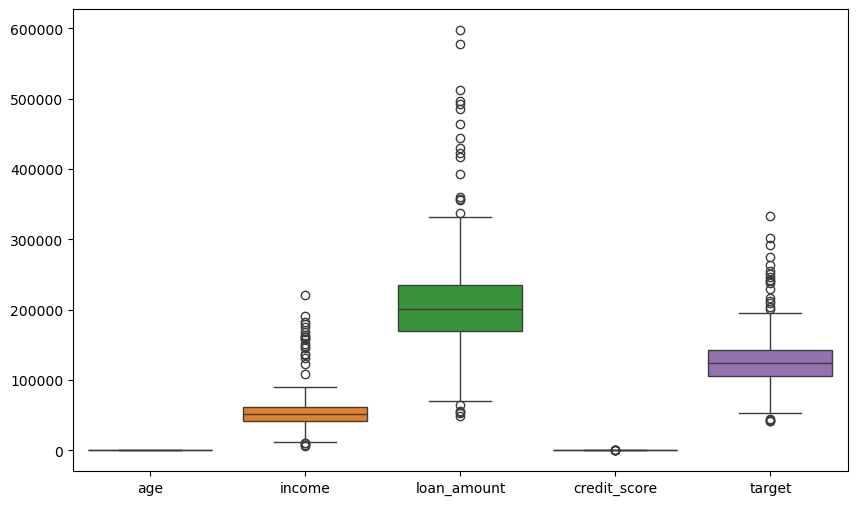

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.show()


In [6]:
median_income=df['income'].median()

df['income'].fillna(median_income,inplace=True)


C:\Users\Arunv\AppData\Local\Temp\ipykernel_26960\1571653766.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(median_income,inplace=True)


In [7]:
median_income=df['loan_amount'].median()

df['loan_amount'].fillna(median_income,inplace=True)


C:\Users\Arunv\AppData\Local\Temp\ipykernel_26960\342565346.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_amount'].fillna(median_income,inplace=True)


In [8]:
median_income=df['credit_score'].median()

df['credit_score'].fillna(median_income,inplace=True)


C:\Users\Arunv\AppData\Local\Temp\ipykernel_26960\3521217047.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['credit_score'].fillna(median_income,inplace=True)


In [9]:
df.isnull().sum()

age                0
income             0
loan_amount        0
credit_score       0
city               0
employment_type    0
target             0
dtype: int64

In [10]:
Q1=df['income'].quantile(0.25)
Q3=df['income'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['income']<lower_bound) | (df['income']>upper_bound)]
len(outliers)

25

In [11]:
Q1=df['loan_amount'].quantile(0.25)
Q3=df['loan_amount'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['loan_amount']<lower_bound) | (df['loan_amount']>upper_bound)]
len(outliers)

24

In [12]:

Q1=df['credit_score'].quantile(0.25)
Q3=df['credit_score'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['credit_score']<lower_bound) | (df['credit_score']>upper_bound)]
len(outliers)

11

In [13]:
def cap_outlier(column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    Lower = Q1 - 1.5*IQR
    Upper = Q3 + 1.5*IQR
    df[column]=df[column].clip(Lower,Upper)

In [14]:
cap_outlier('income')
cap_outlier('loan_amount')
cap_outlier('credit_score')


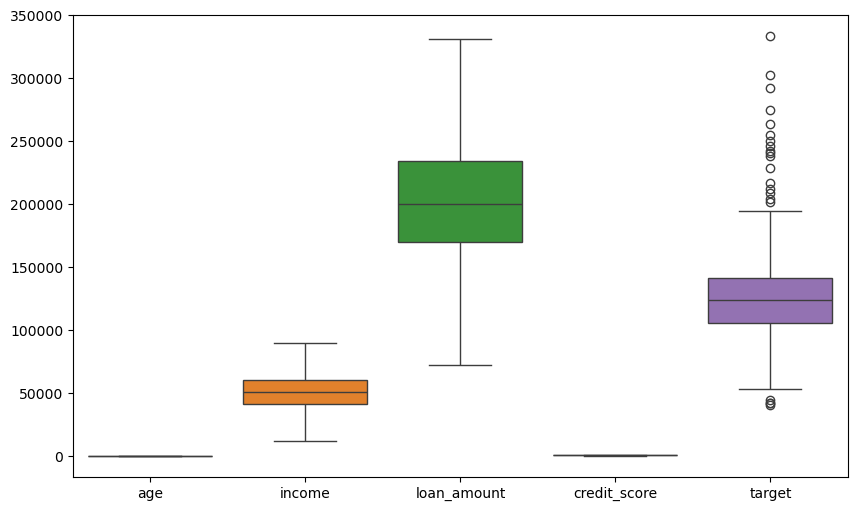

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.show()


In [16]:
df.shape

(1000, 7)

In [17]:
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [18]:
df['city'].value_counts()

city
Hyderabad    260
Chennai      259
Bangalore    256
Mumbai       225
Name: count, dtype: int64

In [19]:
df['employment_type'].value_counts()

employment_type
Self-Employed    356
Salaried         325
Unemployed       319
Name: count, dtype: int64

In [20]:
#handle the categoricla variables by one hot encoding
cat=['city','employment_type']
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(sparse_output=False)

encoded_data=encoder.fit_transform(df[cat])

encoded_data



array([[0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 1., 0., 0.]], shape=(1000, 7))

In [21]:
#encoded data coverted to data frame
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(cat))
encoded_df


,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
995,0.0,1.0,0.0,0.0,1.0,0.0,0.0
996,1.0,0.0,0.0,0.0,0.0,1.0,0.0
997,0.0,0.0,1.0,0.0,0.0,0.0,1.0
998,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [22]:
#concatenate the encoded data framw with orginal dataframe (excluding the categorical columns )

df=pd.concat([df.drop(columns=cat),encoded_df.astype(int)],axis=1)  #drop the cat columns and concatinate the encoded dataframe with the original dataframe
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,25903.305196,286348.192562,789.476075,158793.631698,0,1,0,0,1,0,0
1,69,53051.954538,180018.190719,596.334039,115596.093965,0,1,0,0,1,0,0
2,46,38654.738821,211234.236288,611.531000,127231.057638,0,1,0,0,1,0,0
3,32,28666.194356,246629.541594,710.171152,145102.187078,0,1,0,0,0,0,1
4,60,40301.406736,129081.713353,622.900855,110623.128404,0,0,1,0,0,0,1


In [23]:
skewness=df.drop(columns=['target']).skew()
skewness

age                             -0.042322
income                           0.187505
loan_amount                      0.134521
credit_score                    -0.044087
city_Bangalore                   1.119865
city_Chennai                     1.101895
city_Hyderabad                   1.095950
city_Mumbai                      1.319085
employment_type_Salaried         0.748388
employment_type_Self-Employed    0.602389
employment_type_Unemployed       0.777843
dtype: float64

In [24]:
normal_skewed_featues=skewness[skewness<0.5].index
Positive_skewed_features=skewness[skewness>0.5].index
Negative_skewed_features=skewness[skewness<-0.5].index

print("Normal : ",normal_skewed_featues)
print("Positive : ",Positive_skewed_features)
print("Negative : ",Negative_skewed_features)

Normal :  Index(['age', 'income', 'loan_amount', 'credit_score'], dtype='object')
Positive :  Index(['city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai',
       'employment_type_Salaried', 'employment_type_Self-Employed',
       'employment_type_Unemployed'],
      dtype='object')
Negative :  Index([], dtype='object')


In [25]:
# check the normal , postive skewness and negative skewness features
normal_skewed_features = skewness[skewness == 0].index.tolist()
positive_skewed_features = skewness[skewness > 0].index.tolist()
negative_skewed_features = skewness[skewness < 0].index.tolist()
 
print("Normal skewed features: ", normal_skewed_features)
print("Positive skewed features: ", positive_skewed_features)
print("Negative skewed features: ", negative_skewed_features)

Normal skewed features:  []
Positive skewed features:  ['income', 'loan_amount', 'city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed']
Negative skewed features:  ['age', 'credit_score']


In [26]:
#handle the scale data
from sklearn.preprocessing import MinMaxScaler
num_cols=['income','loan_amount']
scaler=MinMaxScaler()
df[num_cols]=scaler.fit_transform(df[num_cols])
df.head()


,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,0.175537,0.825684,789.476075,158793.631698,0,1,0,0,1,0,0
1,69,0.526493,0.414927,596.334039,115596.093965,0,1,0,0,1,0,0
2,46,0.340377,0.535516,611.531000,127231.057638,0,1,0,0,1,0,0
3,32,0.211253,0.672249,710.171152,145102.187078,0,1,0,0,0,0,1
4,60,0.361664,0.218158,622.900855,110623.128404,0,0,1,0,0,0,1


In [27]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

df['credit_score']=scaler.fit_transform(df[['credit_score']])


In [28]:
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,0.175537,0.825684,2.013602,158793.631698,0,1,0,0,1,0,0
1,69,0.526493,0.414927,-0.763656,115596.093965,0,1,0,0,1,0,0
2,46,0.340377,0.535516,-0.545133,127231.057638,0,1,0,0,1,0,0
3,32,0.211253,0.672249,0.873248,145102.187078,0,1,0,0,0,0,1
4,60,0.361664,0.218158,-0.381642,110623.128404,0,0,1,0,0,0,1


In [29]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['target'])
y=df['target']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#model 1

from sklearn.neighbors import KNeighborsRegressor

knn_regressor = KNeighborsRegressor(n_neighbors=5)

knn_regressor.fit(x_train,y_train)

y_pred=knn_regressor.predict(x_test)

In [31]:
from sklearn.metrics import mean_squared_error,r2_score

mse=mean_squared_error(y_test,y_pred)

r2=r2_score(y_test,y_pred)

print("mean squared error:",mse)
print("r2 score:",r2)

mean squared error: 1150544257.404101
r2 score: -0.10279143852101558


In [32]:
mse_values=[]
k_values=range(1,21)

for k in k_values:
    knn_regressor=KNeighborsRegressor(n_neighbors=k)
    
    knn_regressor.fit(x_train,y_train)
    
    y_pred=knn_regressor.predict(x_test)
    
    mse=mean_squared_error(y_test,y_pred)
    
    mse_values.append(mse)

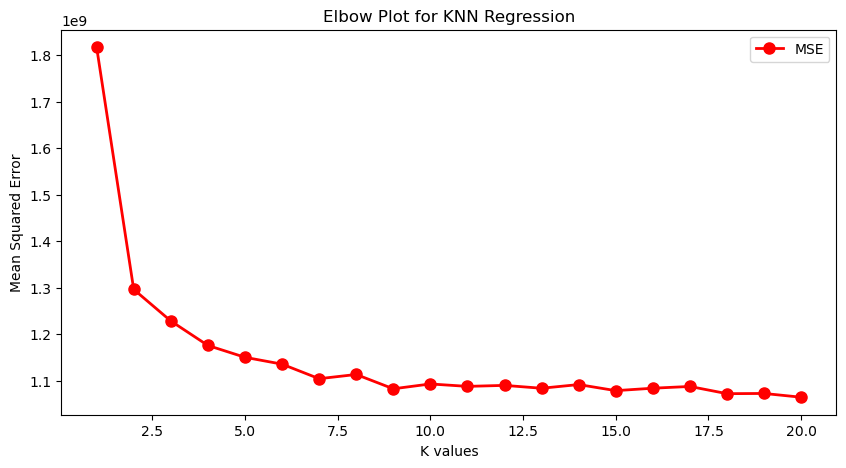

In [33]:
# plot the elbow plot
plt.figure(figsize=(10,5))
plt.plot(k_values, mse_values, marker='o',color='red',linewidth=2,markersize=8,label='MSE',)
plt.title("Elbow Plot for KNN Regression")
plt.xlabel("K values")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

train_r2 = linear_model.score(X_train, y_train)
test_r2 = linear_model.score(X_test, y_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5

print("Linear Regression Results")
print(f"Training R2 score: {train_r2:.4f}")
print(f"Testing R2 score: {test_r2:.4f}")
print(f"Training MAE: {train_mae:.2f}")
print(f"Testing MAE: {test_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Testing RMSE: {test_rmse:.2f}")


Linear Regression Results
Training R2 score: 0.7867
Testing R2 score: 0.8042
Training MAE: 9271.53
Testing MAE: 10165.01
Training RMSE: 14399.03
Testing RMSE: 14293.65
